In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier,
                              VotingClassifier, StackingClassifier, HistGradientBoostingClassifier)
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")

### Task 1: Baseline with Single Models

Load the data and establish individual model baselines.

1. Load the Wine Quality dataset and create a binary target:

```python
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good
```

2. Explore the dataset: how many features? What's the class distribution of `quality_label`? Is the dataset imbalanced?
3. Separate features and target. Drop the original `quality` column.
4. Split into training and test sets (80/20, `stratify=y`, `random_state=42`).
5. Scale features using `StandardScaler`.
6. Fit three baseline models:
   - `DecisionTreeClassifier(random_state=42)`
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `KNeighborsClassifier()`

7. Report **accuracy** and **F1 score** (use `f1_score` with `average="binary"`) for each on the test set. Organize results in a table.

In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=";")
wine["quality_label"] = (wine["quality"] >= 7).astype(int)  # 1 = good, 0 = not good

In [4]:
wine.columns.tolist()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality',
 'quality_label']

In [5]:
wine['quality_label'].unique()

array([0, 1])

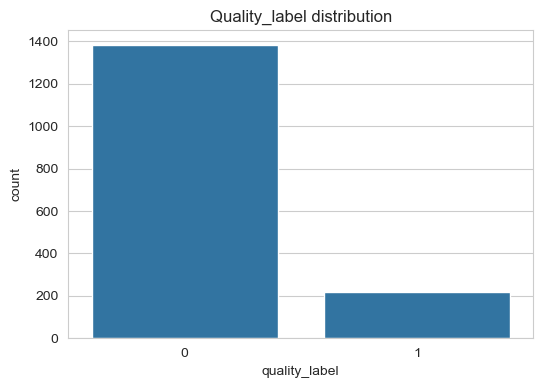

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='quality_label', data=wine)
plt.title('Quality_label distribution')
plt.show()

In [7]:
wine['quality_label'].value_counts()

quality_label
0    1382
1     217
Name: count, dtype: int64

The dataset is imbalanced because the majority class (not good wine) makes up about 86% of the data, while the minority class (good wine) is only about 14%.

In [8]:
X=wine.drop(columns = ['quality', 'quality_label'])
y=wine['quality']  

In [9]:
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [10]:
X_train, X_test, y_tain, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=42)

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [12]:
results = []

models = {
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "LogisticRegression" : LogisticRegression(max_iter=1000, random_state=42),
    "KNeighborsClassifier" : KNeighborsClassifier()
} 

for name, model in models.items():
    model.fit(X_train_scaled, y_tain)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro") 

    results.append({
        "Model" : name,
        "Accuracy score" : accuracy,
        "F1 score" : f1
    })

result_df = pd.DataFrame(results)
print(result_df) 

                    Model  Accuracy score  F1 score
0  DecisionTreeClassifier        0.609375  0.395870
1      LogisticRegression        0.590625  0.277628
2    KNeighborsClassifier        0.609375  0.310720


### Task 2: Bagging & Random Forest

Explore how bagging improves on individual decision trees.

1. Fit a `BaggingClassifier` with a `DecisionTreeClassifier` as the base estimator (`n_estimators=100`, `oob_score=True`, `random_state=42`).
2. Fit a `RandomForestClassifier` (`n_estimators=100`, `oob_score=True`, `random_state=42`).
3. For both models, report:
   - Out-of-bag (OOB) score
   - Test accuracy and F1 score
4. Compare: How does bagging improve over the single Decision Tree from Task 1?
5. Plot the **top 10 feature importances** from the Random Forest as a horizontal bar chart. Which features matter most for predicting wine quality?
6. In a markdown cell, explain: Why does Random Forest typically outperform a single Decision Tree? What role does randomness play?

In [13]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    oob_score=True,
    random_state = 42
)
bagging.fit(X_train_scaled, y_tain)

y_pred_bagging = bagging.predict(X_test_scaled) 
print(f"Bagging Classifier OOB score: {bagging.oob_score_:.4f}, Accuracy: {accuracy_score(y_test, y_pred_bagging)}, F1 score: {f1_score(y_test, y_pred_bagging, average="macro")}") 

Bagging Classifier OOB score: 0.6896, Accuracy: 0.671875, F1 score: 0.3939272882475686


In [14]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state = 42
) 

random_forest.fit(X_train_scaled, y_tain)

y_pred_random = random_forest.predict(X_test_scaled)
print(f"RandomForest Classifier OOB score: {random_forest.oob_score_:.4f}, Accuracy: {accuracy_score(y_test, y_pred_random)}, F1 score: {f1_score(y_test, y_pred_random, average="macro")}")

RandomForest Classifier OOB score: 0.6974, Accuracy: 0.675, F1 score: 0.40364275913410674


In [15]:
results = pd.DataFrame({
    "Model": ["Bagging", "Random Forest"],
    "OOB Score": [bagging.oob_score_, random_forest.oob_score_],
    "Accuracy": [accuracy_score(y_test, y_pred_bagging), accuracy_score(y_test, y_pred_random)],
    "F1 Score": [f1_score(y_test, y_pred_bagging, average="macro"), f1_score(y_test, y_pred_random, average="macro")]
}) 

In [16]:
results

,Model,OOB Score,Accuracy,F1 Score
0,Bagging,0.689601,0.671875,0.393927
1,Random Forest,0.697420,0.675000,0.403643


In task one Decision tree accuracy was  0.609375  and f1 score was 0.395870 but now, they are 0.671875	and 0.393927. We can observe slight improvement in accuracy but the same cannot be said for f1 score, it has even slightly decreased.  

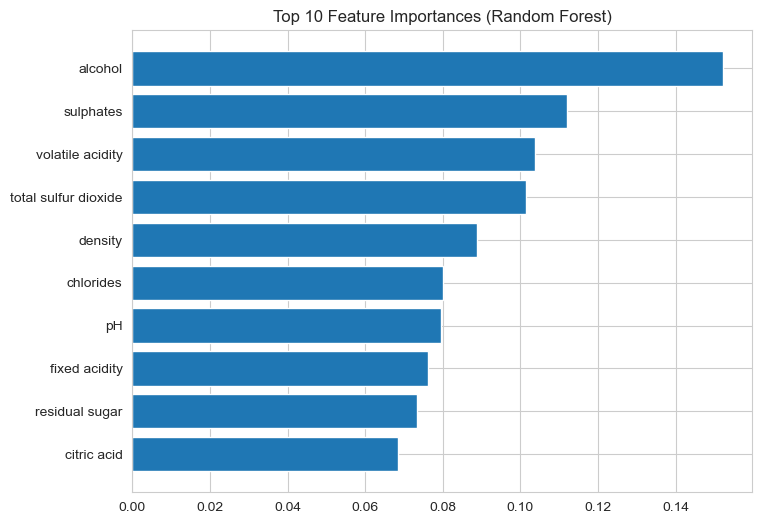

In [17]:
importances = random_forest.feature_importances_ 
features = wine.drop(columns = ['quality', 'quality_label']).columns

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,6))
plt.barh(features[indices], importances[indices])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.show() 

the feature names in the graph matter most for the target.

Random Forest performs better because it reduces overfitting by combining many decision trees trained on different random subsets of data and features. While a single decision tree can easily memorize training data, Random Forest averages multiple trees, making predictions more stable and generalizable.

### Task 3: Boosting 

Train boosting models and analyze how they learn. 

1. Fit the following boosting models:
   - `AdaBoostClassifier(n_estimators=100, random_state=42)`
   - `GradientBoostingClassifier(n_estimators=100, random_state=42)`
   - (Optional) `HistGradientBoostingClassifier(max_iter=100, random_state=42)` — scikit-learn's faster implementation

2. Report accuracy and F1 for each on the test set.

3. **Learning curves:** For `GradientBoostingClassifier`, use `staged_predict` to compute training and test accuracy at each boosting stage (1 to 100 estimators). Plot both curves on the same figure. At what point does the model start to overfit (if at all)?

4. In a markdown cell, compare AdaBoost and GradientBoosting: How do they differ in their approach? When might you prefer one over the other?


In [18]:
model_adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
model_adaboost.fit(X_train_scaled, y_tain)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [19]:
y_pred_adaboost = model_adaboost.predict(X_test_scaled) 

In [20]:
acc_adaboost = accuracy_score(y_test, y_pred_adaboost)
f1_adaboost = f1_score(y_test, y_pred_adaboost, average="macro") 

In [21]:
print(acc_adaboost)
print(f1_adaboost)

0.553125
0.35718984649398994


In [22]:
model_gradient = GradientBoostingClassifier(n_estimators=100, random_state=42) 
model_gradient.fit(X_train_scaled, y_tain)
y_pred_gradient = model_gradient.predict(X_test_scaled) 
acc_gradient = accuracy_score(y_test, y_pred_gradient)
f1_gradient = f1_score(y_test, y_pred_gradient, average="macro") 

In [23]:
print(acc_gradient)
print(f1_gradient) 

0.65
0.41900999941343353


In [24]:
model_hist = HistGradientBoostingClassifier(max_iter=100, random_state=42)
model_hist.fit(X_train_scaled, y_tain)
y_pred_hist = model_hist.predict(X_test_scaled)
acc_hist = accuracy_score(y_test, y_pred_hist)
f1_hist = f1_score(y_test, y_pred_hist, average="macro") 

In [25]:
print(acc_hist)
print(f1_hist)

0.65625
0.39738508629509034


In [26]:
y_train_pred = model_gradient.predict(X_train_scaled) 

In [27]:
import numpy as np
import matplotlib.pyplot as plt

train_acc = []
test_acc = []

for y_train_pred, y_pred_gradient in zip(model_gradient.staged_predict(X_train_scaled), model_gradient.staged_predict(X_test_scaled)):
    train_acc.append(accuracy_score(y_tain, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_pred_gradient))  

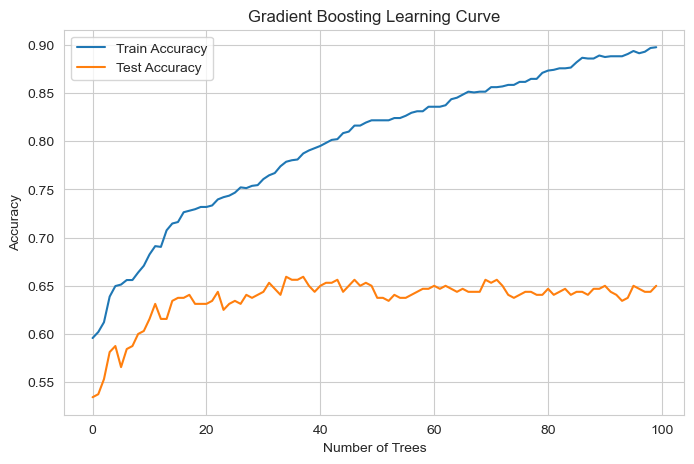

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

There we see accuracy=0.65 point train continue to learn but test stops and fluctuates. 

AdaBoost

AdaBoost focuses on misclassified samples by increasing their weights after each iteration. It builds weak learners sequentially and emphasizes difficult cases.

Gradient Boosting

Gradient Boosting improves models by optimizing a loss function using gradient descent. Each new tree corrects the errors of the previous ensemble.

### Task 4: Stacking & Voting

Combine your best models into meta-ensembles.

1. **Voting classifier:** Select the 3 best-performing models from Tasks 1–3. Build a `VotingClassifier` with `voting="soft"`. Report accuracy and F1 on the test set.

2. **Stacking classifier:** Using the same 3 base models, build a `StackingClassifier` with `LogisticRegression()` as the `final_estimator`. Report accuracy and F1 on the test set.

3. **Final comparison table:** Create a comprehensive DataFrame comparing **all** models from the entire lab (baselines, bagging, Random Forest, boosting, voting, stacking) with their accuracy and F1 scores. Sort by F1 descending.

4. In a concluding markdown cell, answer:
   - Which ensemble strategy performed best on this dataset?
   - Was the improvement over single models significant?
   - What are the trade-offs (training time, interpretability, complexity) of using ensemble methods?
   - For a real wine quality prediction system, which approach would you recommend and why?

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression(max_iter=1000) 

In [30]:
voting = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("lr", lr)
    ],
    voting="soft"
)

voting.fit(X_train_scaled, y_tain)

y_pred_vote = voting.predict(X_test_scaled)

vote_acc = accuracy_score(y_test, y_pred_vote)
vote_f1 = f1_score(y_test, y_pred_vote, average="macro") 

In [31]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[
        ("rf", rf),
        ("gb", gb),
        ("lr", lr)
    ],
    final_estimator=LogisticRegression(max_iter=1000)
)

stack.fit(X_train_scaled, y_tain)

y_pred_stack = stack.predict(X_test_scaled)

stack_acc = accuracy_score(y_test, y_pred_stack)
stack_f1 = f1_score(y_test, y_pred_stack, average="macro")

In [33]:
stack_acc 

0.66875

In [34]:
stack_f1 

0.3336320191158901

In [32]:
log_acc = result_df[result_df["Model"] == "LogisticRegression"]["Accuracy score"].values[0]
dt_acc = result_df[result_df["Model"] == "DecisionTreeClassifier"]["Accuracy score"].values[0]
knn_acc = result_df[result_df["Model"] == "KNeighborsClassifier"]["Accuracy score"].values[0]

log_f1 = result_df[result_df["Model"] == "LogisticRegression"]["F1 score"].values[0]
dt_f1 = result_df[result_df["Model"] == "DecisionTreeClassifier"]["F1 score"].values[0]
knn_f1 = result_df[result_df["Model"] == "KNeighborsClassifier"]["F1 score"].values[0] 

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "Bagging",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "HistGB",
        "Voting",
        "Stacking"
    ],
    "Accuracy": [
        log_acc, dt_acc, knn_acc,
        accuracy_score(y_test, y_pred_bagging), accuracy_score(y_test, y_pred_random),
        acc_adaboost, acc_gradient, acc_hist,
        vote_acc, stack_acc
    ],
    "F1 Score": [
        log_f1, dt_f1, knn_f1,
        f1_score(y_test, y_pred_bagging, average="macro"), f1_score(y_test, y_pred_random, average="macro"),
        f1_adaboost, f1_gradient, f1_hist,
        vote_f1, stack_f1
    ]
})

results.sort_values(by="F1 Score", ascending=False) 

,Model,Accuracy,F1 Score
8,Voting,0.687500,0.438526
6,Gradient Boosting,0.650000,0.419010
4,Random Forest,0.675000,0.403643
7,HistGB,0.656250,0.397385
1,Decision Tree,0.609375,0.395870
3,Bagging,0.671875,0.393927
5,AdaBoost,0.553125,0.357190
9,Stacking,0.668750,0.333632
2,KNN,0.609375,0.310720
0,Logistic Regression,0.590625,0.277628


The Stacking classifier performed worse than individual ensemble models, with an accuracy of 0.67 and a low F1 score. This suggests that the stacking approach did not effectively combine the base models. A likely reason is the lack of diversity among base models and the use of a simple logistic regression as the meta-learner. Additionally, class imbalance may have negatively impacted the model’s ability to correctly predict the minority class.